In [ ]:
import torch 
from torch import nn
import numpy as np
import pandas as pd
import dataclasses
from dataclasses import dataclass, field
from typing import List
from torch.utils.data import Dataset, DataLoader, TensorDataset
from collections.abc import Iterable
from basic_conv1d import bn_drop_lin
from clinical_ts.template_modules import ShapeConfig
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, roc_curve, auc
import sys
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import matplotlib
matplotlib.use('Agg')
import os
import warnings
warnings.filterwarnings('ignore')
import mlp_models
from scipy.interpolate import make_interp_spline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from xgboost import XGBClassifier

In [ ]:
# Get the absolute path of the parent folder (MD-F)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# Add it to Python's search path if it's not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# --- NOW your existing imports will work perfectly ---
from template_modules import EncoderStaticBase, EncoderStaticBaseConfig
from mlp_models import BasicEncoderStaticMLP

# Table of content
## 1. Model initialization 
## 2. Loading the model
## 3. Extract ICU_24h predictions 
## 4. Class predictions at different thresholds using the BasicEncoderStaticMLP
##### 4.1 threshold function to calculate FP, FN, TP, TN
##### 4.2 Confusion matrix + sensitivity + specificity for icu_24h using MLP
##### 4.3 ROC curve (sensitivity vs specificity)
##### 4.4 finding a threshold where sensitivity is 80% (using MLP)
## 5. Monte Carlo Dropout for calculating uncertainty
##### 5.1 exclude labels with nan values
##### 5.2 Uncertainty distribution across TP and FP
##### 5.3 Calculating the confusion matrix at threshold=0.13
## 6. Q Model 
##### 6.1 Q Model (MLP+XGBoost)
##### 6.2 Q model (MC+XGBoost)
##### 6.3 Q model (MC + XGBoost) + FP reduction plot

#  1. Model initialization (BasicEncoderStaticMLP)

In [20]:

# ----------------------------------------
@dataclass
class MLPConfig:
    embedding_dims: List[int] = field(default_factory=lambda: [16, 16, 16])
    vocab_sizes: List[int]    = field(default_factory=lambda: [2, 5, 5])
    lin_ftrs: List[int]       = field(default_factory=lambda: [128, 128, 128])
    dropout: float = 0.5
    batch_norm: bool = True

@dataclass
class ShapeCfg:
    static_dim: int = 0
    static_dim_cat: int = 0
    channels: int = 0
    length: int = 0
    sequence_last: bool = False
    channels2: int = 0

## 2. Loading the model

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Construct the path to the parent folder dynamically
model_path = os.path.join("..", "best_realmlp.pt")

encoder = torch.load(
    model_path,
    map_location=device,
    weights_only=False  # Required for loading full custom model objects
)
encoder.eval()

BasicEncoderStaticMLP(
  (embeddings): ModuleList(
    (0): Embedding(2, 2)
    (1): Embedding(5, 5)
  )
  (layers): Sequential(
    (0): BatchNorm1d(471, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=471, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU(inplace=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Dropout(p=0.25, inplace=False)
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): ReLU(inplace=True)
    (12): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): Dropout(p=0.5, inplace=False)
    (14): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [22]:
DATA_PATH   = r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv'
BATCH_SIZE = 64
# ============================================================
# 1. Load & preprocess data
# ============================================================
print("\nLoading data...")
df = pd.read_csv(DATA_PATH, low_memory=False)

input_cols    = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
df_train      = df[df['general_strat_fold'] < 18]
train_medians = df_train[input_cols].median().to_dict()
for c in [c for c, v in df_train[input_cols].isna().sum().items() if v > 0]:
    df.loc[df[c].isna(), c] = train_medians[c]
df = df.copy()

unique_counts = {c: len(np.unique(np.array(df[c]))) for c in input_cols}
cat_features  = [c for c, v in unique_counts.items()
                 if v < 10 and not c.endswith("nan") and not c.startswith("labvalues")]
cont_features = [c for c in input_cols if c not in cat_features]

df["vitals_acuity"] = df["vitals_acuity"].apply(lambda x: int(x) - 1)
lbl_eth = ['demographics_ethnicity_asian','demographics_ethnicity_black/african',
           'demographics_ethnicity_hispanic/latino','demographics_ethnicity_other',
           'demographics_ethnicity_white']
df["demographics_ethnicity"] = df.apply(lambda r: np.where([r[c] for c in lbl_eth])[0][0], axis=1)
df.drop(lbl_eth, axis=1, inplace=True)

input_cols    = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
cat_features  = [c for c in input_cols if c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

lbl_itos = ["mortality_1d", "icu_24h", "cardiac_arrest", "vasopressors"]
for c in lbl_itos:
    df["deterioration_" + c] = df["deterioration_" + c].replace(-999., np.nan)

val_df  = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df = df[df['general_strat_fold'] == 19].reset_index(drop=True)
val_df  = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
print(f"Val: {len(val_df)}, Test: {len(test_df)}")

# ============================================================
# 2. Dataset & DataLoader
# ============================================================
class TabularDataset(Dataset):
    def __init__(self, df, cont_f, cat_f, lbl_cols):
        self.cont   = torch.tensor(df[cont_f].values, dtype=torch.float32)
        self.cat    = torch.tensor(df[cat_f].values,  dtype=torch.long)
        self.labels = torch.tensor(df[["deterioration_"+c for c in lbl_cols]].values, dtype=torch.float32)
    def __len__(self): return len(self.cont)
    def __getitem__(self, i): return self.cont[i], self.cat[i], self.labels[i]

val_loader  = DataLoader(TabularDataset(val_df,  cont_features, cat_features, lbl_itos),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(TabularDataset(test_df, cont_features, cat_features, lbl_itos),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)



Loading data...
Val: 5824, Test: 6080


# 3. Extract ICU_24h predictions 

In [23]:

# Predict on validation set
# ----------------------------------------
all_preds, all_labels = [], []

with torch.no_grad():

    for cont, cat, labels in val_loader:

        cont = cont.to(device)
        cat  = cat.to(device)

        out = encoder(static=cont, static_cat=cat)

        probs = torch.sigmoid(out["static"])

        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)


# ----------------------------------------
# Extract ICU_24h predictions and labels
# ----------------------------------------
target_idx = 1

mask = ~np.isnan(all_labels[:, target_idx])

y_true = all_labels[:, target_idx]
y_prob = all_preds[:, target_idx]


# ----------------------------------------
# Save to CSV
# ----------------------------------------
results = pd.DataFrame({
    "ICU_24h_true": y_true.astype(int),
    "ICU_24h_probability": y_prob
})


print(results)


      ICU_24h_true  ICU_24h_probability
0                1             0.004015
1                0             0.014553
2                0             0.005785
3                0             0.133368
4                0             0.143087
...            ...                  ...
5819             0             0.021184
5820             0             0.254698
5821             0             0.027617
5822             1             0.026268
5823             0             0.009481

[5824 rows x 2 columns]


# 4. Class predictions at different thresholds using the BasicEncoderStaticMLP

## 4.1 threshold function to calculate FP, FN, TP, TN

In [24]:

# Set diffrent thresholds from 0 all the way to 1
def evaluate_thresholds(y_true, y_prob, thresholds=np.arange(0.01, 1, 0.01), cFP=1,
    cFN=1):
    
    results = []

    for thr in thresholds:

        y_pred = (y_prob >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn )   # recall
        specificity = tn / (tn + fp )

        precision = tp / (tp + fp)
        # Cost function
        cost = cFP * fp + cFN * fn

        results.append({
            "threshold": thr,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "False Positive": fp,
            "True Positive": tp,
            "False Negative": fn,
            "True Negative": tn,
            "cost": cost
        })

    return pd.DataFrame(results)

## 4.2 Confusion matrix + sensitivity + specificity for icu_24h using MLP

In [42]:
all_results = []

label_name = ['icu_24h']


mask = ~np.isnan(all_labels[:, 1])
y_true = all_labels[mask, 1]
y_prob = all_preds[mask, 1]

df_thr = evaluate_thresholds(y_true, y_prob, cFP=1, cFN=1)

# Force a completely independent copy and assign label
df_temp = df_thr[[
    "threshold",
    "sensitivity",
    "specificity",
    "precision",
    "False Positive",
    "False Negative",
    "cost"
]].copy()

print("\n")
print("=" * 60)
print(label_name)
print("=" * 60)

result_icu_prediction = df_temp

print(result_icu_prediction.head())



['icu_24h']
   threshold  sensitivity  specificity  precision  False Positive  \
0       0.01     0.993921     0.192659   0.135938            4157   
1       0.02     0.966565     0.409788   0.173061            3039   
2       0.03     0.940729     0.544572   0.208839            2345   
3       0.04     0.908815     0.639347   0.243585            1857   
4       0.05     0.870821     0.710235   0.277482            1492   

   False Negative  cost  
0               4  4161  
1              22  3061  
2              39  2384  
3              60  1917  
4              85  1577  


### 4.3 ROC curve (sensitivity vs specificity)

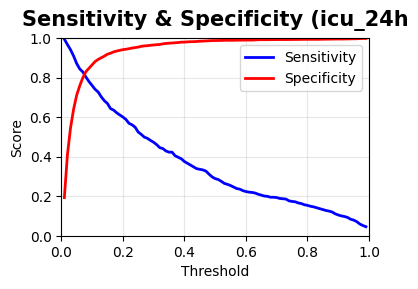

In [81]:
%matplotlib inline
df_mlp = result_icu_prediction
plt.figure(figsize=(4,3))
plt.plot(df_mlp["threshold"], df_mlp["sensitivity"], label="Sensitivity", color="blue", linewidth=2)
plt.plot(df_mlp["threshold"], df_mlp["specificity"], label="Specificity", color="red", linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

plt.title("Sensitivity & Specificity (icu_24h", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.4 finding a threshold where sensitivity is 80% (using MLP)

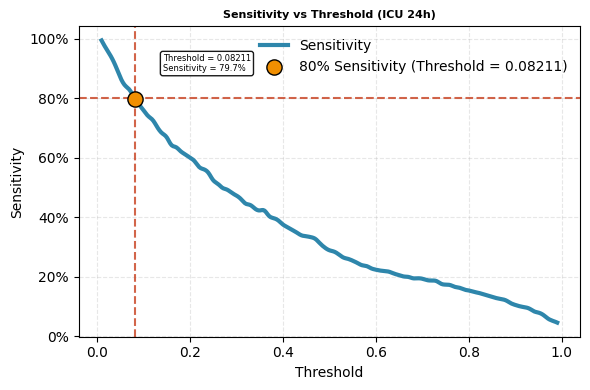

In [ ]:
# Filter and sort data
df_plot = df_mlp.sort_values("threshold")

x = df_plot["threshold"].values
y = df_plot["sensitivity"].values

# Smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

# Find threshold corresponding to 80% sensitivity
target_sens = 0.80

idx = np.argmin(np.abs(y_smooth - target_sens))
thr = x_smooth[idx]
sens = y_smooth[idx]

plt.figure(figsize=(6, 4))

# Sensitivity curve
plt.plot(
    x_smooth,
    y_smooth,
    color="#2E86AB",
    linewidth=3,
    label="Sensitivity"
)

# Mark 80% sensitivity point
plt.scatter(
    thr,
    sens,
    color="#F18F01",
    s=120,
    edgecolor="black",
    zorder=5,
    label=f"80% Sensitivity (Threshold = {thr:.5f})"
)

# Reference lines
plt.axvline(
    thr,
    color="#C73E1D",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

plt.axhline(
    target_sens,
    color="#C73E1D",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Annotation
plt.annotate(
    f"Threshold = {thr:.5f}\nSensitivity = {sens:.1%}",
    (thr, sens),
    xytext=(20, 20),
    textcoords="offset points",
    fontsize=6,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9)
)

# Titles and labels
plt.title(
    "Sensitivity vs Threshold (ICU 24h)",
    fontsize=8,
    fontweight="bold"
)
plt.xlabel("Threshold")
plt.ylabel("Sensitivity")

# Optional: show y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

# 5. Monte Carlo Dropout 

In [ ]:
def mc_dropout_predict(model, test_loader, device, n_samples=50):

    model.train()  # IMPORTANT: keep dropout active

    all_mean_preds = []
    all_uncertainties = []
    all_labels = []

    with torch.no_grad():

        for cont, cat, labels in test_loader:

            cont = cont.to(device)
            cat  = cat.to(device)

            mc_samples = []

            # ----------------------------------------
            # Multiple stochastic forward passes
            # ----------------------------------------
            for _ in range(n_samples):

                out = model(static=cont, static_cat=cat)
                probs = torch.sigmoid(out["static"])

                mc_samples.append(probs.cpu().numpy())

            mc_samples = np.array(mc_samples)

            # -------------
            # 
            # ---------------------------
            # MC statistics
            # ----------------------------------------
            mean_preds = mc_samples.mean(axis=0)
            uncertainty = mc_samples.std(axis=0)

            all_mean_preds.append(mean_preds)
            all_uncertainties.append(uncertainty)
            all_labels.append(labels.numpy())

    all_mean_preds = np.concatenate(all_mean_preds, axis=0)
    all_uncertainties = np.concatenate(all_uncertainties, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_mean_preds, all_uncertainties, all_labels

In [47]:
print("\nRunning Monte Carlo Dropout...")

all_mean_preds, all_uncertainties, y_true = mc_dropout_predict(
    encoder,
    test_loader,
    device,
    n_samples=50
)


Running Monte Carlo Dropout...


### 5.1 exclude labels with nan values

In [ ]:
y_test = y_true[:, 0]
pred_prob = all_mean_preds[:, 0]

mask = ~np.isnan(y_test)

y_test = y_test[mask]
pred_prob = pred_prob[mask]


y_class = (pred_prob >= 0.14).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_class).ravel()
print(f"Baseline FP = {fp}")

Baseline FP = 36


### 5.2 Uncertainty distribution across TP and FP

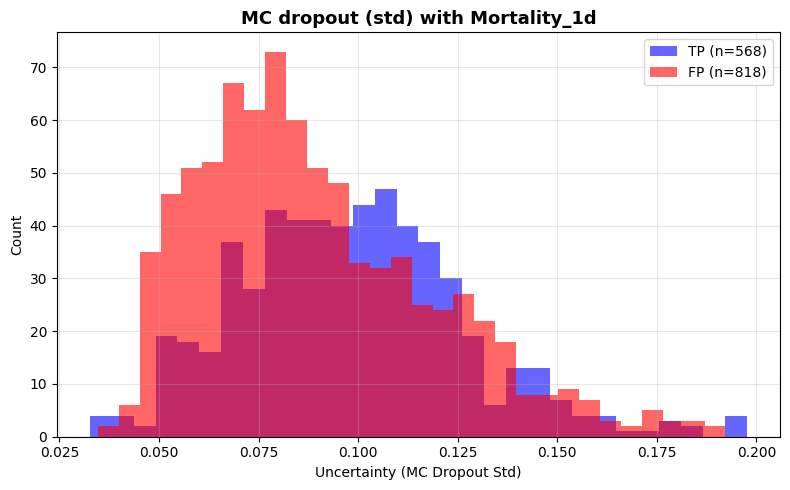

In [52]:
threshold=0.13  # sensitivity = 80%
mask = ~np.isnan(y_true[:, 1])

y_true_i      = y_true[mask, 1]
mean_preds_i  = all_mean_preds[mask, 1]
uncertainty_i = all_uncertainties[mask, 1]

# Classify into TP and FP
predicted_pos = mean_preds_i >= threshold
tp_mask       = (predicted_pos) & (y_true_i == 1)
fp_mask       = (predicted_pos) & (y_true_i == 0)

tp_uncertainty = uncertainty_i[tp_mask]
fp_uncertainty = uncertainty_i[fp_mask]

plt.figure(figsize=(8, 5))
plt.hist(tp_uncertainty, bins=30, alpha=0.6, color="blue", label=f"TP (n={tp_mask.sum()})")
plt.hist(fp_uncertainty, bins=30, alpha=0.6, color="red",  label=f"FP (n={fp_mask.sum()})")

plt.title("MC dropout (std) with Mortality_1d", fontsize=13, fontweight="bold")
plt.xlabel("Uncertainty (MC Dropout Std)")
plt.ylabel("Count")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("uncertainty_tp_fp_icu_24h.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.6 Calculating the confusion matrix at threshold=0.13

In [ ]:
threshold = 0.13

# ----------------------------
# ICU_24h ONLY
# ----------------------------
y_test      = y_true[:, 1]
pred_prob   = all_mean_preds[:, 1]
uncertainty = all_uncertainties[:, 1]

uncertainty_thresholds = [0.05, 0.1, 0.25]

results = []

for u_cut in uncertainty_thresholds:
    for group_name, mask_unc in [
        (f"≤ {u_cut}", uncertainty <= u_cut),
        (f"> {u_cut}", uncertainty > u_cut),
    ]:
        mask = mask_unc & (~np.isnan(y_test))
        y_t  = y_test[mask]
        y_p  = pred_prob[mask]

        y_pred = (y_p >= threshold).astype(int)

        if len(y_t) == 0 or len(np.unique(y_t)) < 2:
            results.append({
                "uncertainty_cutoff" : u_cut,
                "group"              : group_name,
                "n_samples"          : len(y_t),
                "TP": 0, "FP": 0, "TN": 0, "FN": 0,
                "sensitivity"        : np.nan,
                "specificity"        : np.nan,
                "precision"          : np.nan,
                "FDR"                : np.nan,
                "FNR (Miss Rate)"    : np.nan,
                "FPR (Fall-out)"     : np.nan,
                "F1"                 : np.nan,
                "AUC"                : np.nan,
            })
            continue

        tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()

        sensitivity = tp / (tp + fn)        if (tp + fn) > 0 else np.nan  # Recall
        specificity = tn / (tn + fp)        if (tn + fp) > 0 else np.nan
        precision   = tp / (tp + fp)        if (tp + fp) > 0 else np.nan
        fdr         = fp / (fp + tp)        if (fp + tp) > 0 else np.nan  # 1 - precision
        fnr         = fn / (fn + tp)        if (fn + tp) > 0 else np.nan  # Miss rate
        fpr         = fp / (fp + tn)        if (fp + tn) > 0 else np.nan  # Fall-out
        f1          = 2 * tp / (2*tp+fp+fn) if (2*tp+fp+fn) > 0 else np.nan
        auc_score   = roc_auc_score(y_t, y_p)

        results.append({
            "uncertainty_cutoff" : u_cut,
            "group"              : group_name,
            "n_samples"          : len(y_t),
            "TP"                 : tp,
            "FP"                 : fp,
            "TN"                 : tn,
            "FN"                 : fn,
            "sensitivity"        : round(sensitivity, 3),
            "specificity"        : round(specificity, 3),
            "precision"          : round(precision,   3),
            "FDR"                : round(fdr,         3),
            "FNR (Miss Rate)"    : round(fnr,         3),
            "FPR (Fall-out)"     : round(fpr,         3),
            "F1"                 : round(f1,           3),
            "AUC"                : round(auc_score,   3),
        })

df = pd.DataFrame(results)

# Display clearly
print(df.to_string(index=False))

# 6. Q-Model (using XGBoost)

In [ ]:
# ============================================================
# 0) IMPORTS
# ============================================================


# ============================================================
# 1) BASE MC DROPOUT OUTPUTS (FROM YOUR PIPELINE)
# ============================================================

target_idx = 1  # ICU_24h

mean_prob = all_mean_preds[:, target_idx]
uncertainty = all_uncertainties[:, target_idx]
y_test = y_true[:, target_idx]

# ------------------------------------------------------------
# ALIGNMENT MASK (REMOVE NaNs)
# ------------------------------------------------------------
mask = ~np.isnan(y_test)

mean_prob = mean_prob[mask]
uncertainty = uncertainty[mask]
y_test = y_test[mask]

# ============================================================
# 2) BASE MODEL PREDICTION
# ============================================================
threshold = 0.11
y_pred = (mean_prob >= threshold).astype(int)

# ============================================================
# 3) CLINICAL FEATURES (CORRECTLY ALIGNED TO test_df)
# ============================================================

# IMPORTANT: SAME SOURCE AS test_loader
df_mc = test_df.reset_index(drop=True)

# apply SAME mask as MC outputs
df_mc = df_mc.iloc[mask].reset_index(drop=True)

clinical_features = df_mc[input_cols].copy()

# safety cleaning
clinical_features = clinical_features.replace([np.inf, -np.inf], np.nan)
clinical_features = clinical_features.fillna(0)

X_clinical = clinical_features.values

# ============================================================
# 4) MC-BASED META FEATURES
# ============================================================

entropy = -(mean_prob * np.log(mean_prob + 1e-8) +
            (1 - mean_prob) * np.log(1 - mean_prob + 1e-8))

margin = np.abs(mean_prob - 0.5)
variance = uncertainty ** 2
spread = uncertainty * 2

# ============================================================
# 5) FINAL FEATURE MATRIX (MC + CLINICAL)
# ============================================================

X_meta = np.hstack([
    mean_prob.reshape(-1, 1),
    uncertainty.reshape(-1, 1),
    entropy.reshape(-1, 1),
    margin.reshape(-1, 1),
    variance.reshape(-1, 1),
    spread.reshape(-1, 1),
    X_clinical
])

# ============================================================
# 6) ERROR LABELS (BINARY - REQUIRED FOR XGBOOST)
# ============================================================

fp = ((y_pred == 1) & (y_test == 0)).astype(int)
fn = ((y_pred == 0) & (y_test == 1)).astype(int)

# FINAL BINARY ERROR LABEL
# 1 = mistake (FP or FN)
# 0 = correct prediction
error_label = (fp | fn).astype(int)

# ============================================================
# 7) TRAIN XGBOOST ERROR MODEL
# ============================================================

error_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=10,   # ↑ increases sensitivity
    eval_metric="logloss"
)

error_model.fit(X_meta, error_label)

# ============================================================
# 8) PREDICT ERROR PROBABILITY
# ============================================================

error_prob = error_model.predict_proba(X_meta)[:, 1]

# ============================================================
# 9) FINAL DECISION (SENSITIVITY-ORIENTED FILTER)
# ============================================================

error_threshold = 0.9  # higher = more sensitive (keeps more positives)

final_pred = np.where(
    (mean_prob >= threshold) & (error_prob < error_threshold),
    1,
    0
)

# ============================================================
# 10) EVALUATION
# ============================================================

tn, fp, fn, tp = confusion_matrix(y_test, final_pred).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n===== FINAL MC + CLINICAL + XGBOOST ERROR MODEL =====")
print(f"TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")


===== FINAL MC + CLINICAL + XGBOOST ERROR MODEL =====
TP: 574, FP: 5, FN: 156, TN: 5316
Sensitivity: 0.7863
Specificity: 0.9991


### 6.2 Q model MC+XGBoost

In [ ]:


# ============================================================
# 1. LOAD FULL DATA (df already exists in your notebook)
# ============================================================

# IMPORTANT: build FULL loader (NOT test_loader)
full_dataset = TabularDataset(df, cont_features, cat_features, lbl_itos)

full_loader = DataLoader(
    full_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

# ============================================================
# 2. RUN MC DROPOUT ON FULL DATA
# ============================================================

print("Running MC Dropout on FULL dataset...")

all_mean_preds, all_uncertainties, y_true = mc_dropout_predict(
    encoder,
    full_loader,
    device,
    n_samples=50
)

# ============================================================
# 3. TARGET SELECTION (ICU_24h)
# ============================================================

target = 1

y_true_full = y_true[:, target]
y_prob_full = all_mean_preds[:, target]
y_unc_full  = all_uncertainties[:, target]

mask = ~np.isnan(y_true_full)

y_target = y_true_full[mask].astype(int)

mc_mean = y_prob_full[mask]
mc_std  = y_unc_full[mask]

# ============================================================
# 4. MC DROPOUT FEATURES (IMPORTANT FOR PERFORMANCE)
# ============================================================

mc_var = mc_std ** 2

entropy = -(
    mc_mean*np.log(mc_mean + 1e-8) +
    (1-mc_mean)*np.log(1-mc_mean + 1e-8)
)

margin05 = np.abs(mc_mean - 0.5)
margin03 = np.abs(mc_mean - 0.3)

spread_proxy = mc_std
inv_margin = 1 / (margin05 + 1e-6)

# extra strong features to improve sensitivity
logit = np.log(mc_mean + 1e-6) - np.log(1 - mc_mean + 1e-6)
confidence = 1 - mc_std

X_mc = np.column_stack([
    mc_mean,
    mc_std,
    mc_var,
    entropy,
    margin05,
    margin03,
    inv_margin,
    spread_proxy,
    logit,
    confidence
])

# ============================================================
# 5. CLINICAL FEATURES (FULL df aligned with MC outputs)
# ============================================================

clinical = df[input_cols].copy()

clinical = clinical.loc[mask].reset_index(drop=True)

X_clinical = clinical.values

# ============================================================
# 6. FINAL FEATURE MATRIX
# ============================================================

X_meta = np.hstack([X_clinical, X_mc])

print("Meta shape:", X_meta.shape)

# ============================================================
# 7. XGBOOST META MODEL (FOCUS ON RECALL / SENSITIVITY)
# ============================================================

pos = y_target.sum()
neg = len(y_target) - pos
scale = neg / (pos + 1e-8)

model = XGBClassifier(
    n_estimators=1500,
    max_depth=6,
    learning_rate=0.02,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    gamma=0,
    reg_lambda=1,
    scale_pos_weight=scale,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_meta, y_target)

# ============================================================
# 8. PREDICT PROBABILITY
# ============================================================

proba = model.predict_proba(X_meta)[:, 1]

# ============================================================
# 9. FIND THRESHOLD FOR ~80% SENSITIVITY
# ============================================================

target_sens = 0.80

best = None
best_gap = 1e9

for t in np.linspace(0.01, 0.99, 300):

    pred = (proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_target, pred).ravel()

    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    gap = abs(sens - target_sens)

    if gap < best_gap:
        best_gap = gap
        best = (t, tp, fp, fn, tn, sens, spec)

# ============================================================
# 10. RESULTS
# ============================================================

t, tp, fp, fn, tn, sens, spec = best

print("\n==============================")
print("MC + CLINICAL + XGBOOST META")
print("==============================")
print(f"Threshold   : {t:.3f}")
print(f"Sensitivity : {sens:.3f}")
print(f"Specificity : {spec:.3f}")
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")

# ============================================================
# 11. BASELINE (MC DROPOUT ONLY)
# ============================================================

mc_baseline = (mc_mean >= 0.11).astype(int)

tn0, fp0, fn0, tp0 = confusion_matrix(y_target, mc_baseline).ravel()

sens0 = tp0 / (tp0 + fn0 + 1e-8)
spec0 = tn0 / (tn0 + fp0 + 1e-8)

print("\n==============================")
print("MC DROPOUT BASELINE")
print("==============================")
print(f"Sensitivity : {sens0:.3f}")
print(f"Specificity : {spec0:.3f}")
print(f"FP={fp0}, FN={fn0}, TP={tp0}, TN={tn0}")

Running MC Dropout on FULL dataset...
Meta shape: (128518, 476)

MC + CLINICAL + XGBOOST META
Threshold   : 0.682
Sensitivity : 0.799
Specificity : 0.966
TP=12520, FP=3829, FN=3157, TN=109012

MC DROPOUT BASELINE
Sensitivity : 0.813
Specificity : 0.819
FP=20427, FN=2927, TP=12750, TN=92414


### 6.3 Q model (MC + XGBoost) + FP reduction plot


===== META MODEL (MC + CLINICAL + XGBOOST) =====
Threshold ~0.80 sensitivity: 0.422
Sensitivity: 0.797
Specificity: 0.932
TP=12500, FP=7721, FN=3177, TN=105120

===== BASELINE (MLP) =====
Sensitivity: 0.813
False Positives: 20427

===== IMPROVEMENT =====
FP reduction: 0.622


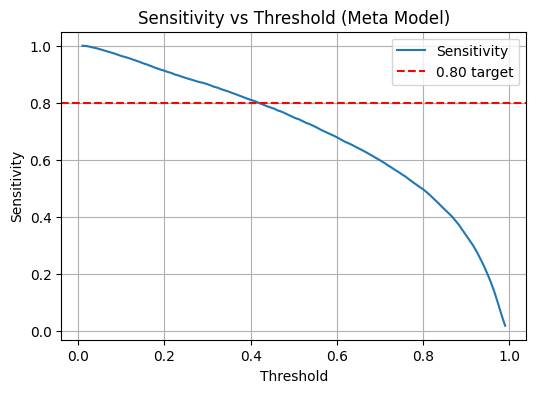

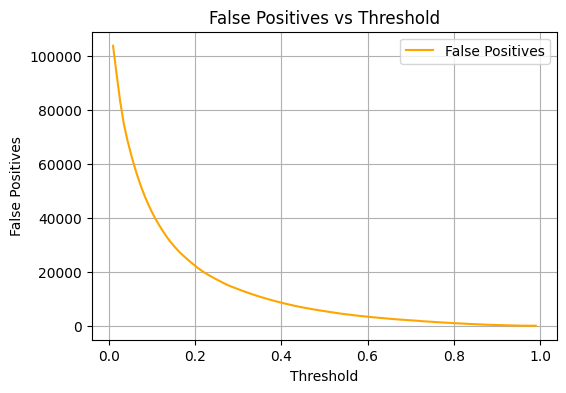

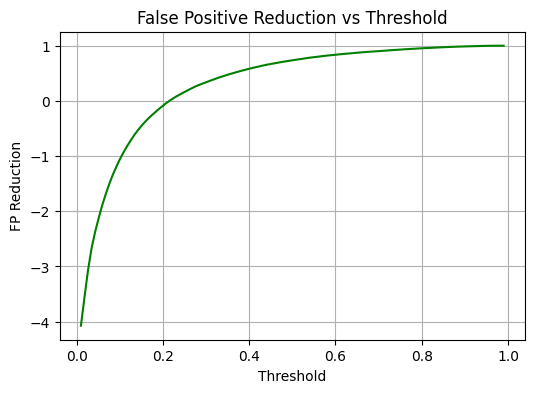

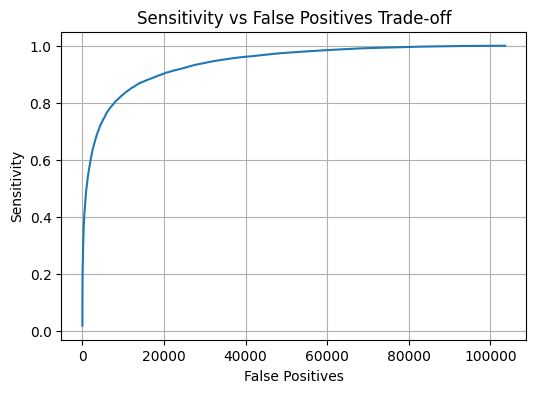

In [ ]:


# ============================================================
# 0. ASSUMPTIONS (already exist in your notebook)
# ============================================================
# y_true              -> (N, 4)
# all_mean_preds      -> MC mean predictions (N, 4)
# all_uncertainties   -> MC std predictions (N, 4)
# df                  -> full dataset aligned with loader
# input_cols         -> clinical feature columns

target = 1  # ICU_24h

# ============================================================
# 1. ALIGN DATA (CRITICAL FIX)
# ============================================================
y_true_full = y_true[:, target]
y_prob_full = all_mean_preds[:, target]
y_unc_full  = all_uncertainties[:, target]

mask = ~np.isnan(y_true_full)

y_true = y_true_full[mask].astype(int)
y_prob = y_prob_full[mask]
y_unc  = y_unc_full[mask]

df_aligned = df.iloc[mask].reset_index(drop=True)

# ============================================================
# 2. MC DROPOUT FEATURES
# ============================================================
mc_mean = y_prob
mc_std  = y_unc
mc_var  = mc_std ** 2

entropy = -(mc_mean*np.log(mc_mean + 1e-8) +
            (1 - mc_mean)*np.log(1 - mc_mean + 1e-8))

margin = np.abs(mc_mean - 0.5)
spread = mc_std

X_mc = np.column_stack([
    mc_mean,
    mc_std,
    mc_var,
    entropy,
    margin,
    spread
])

# ============================================================
# 3. CLINICAL FEATURES (FULL SET)
# ============================================================
X_clinical = df_aligned[input_cols].values

# optional safety
X_clinical = np.nan_to_num(X_clinical)

# ============================================================
# 4. META FEATURES
# ============================================================
X_meta = np.hstack([X_clinical, X_mc])

# ============================================================
# 5. BASELINE (MLP ONLY)
# ============================================================
baseline_threshold = 0.11
baseline_pred = (y_prob >= baseline_threshold).astype(int)

tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_true, baseline_pred).ravel()

baseline_sens = tp_b / (tp_b + fn_b + 1e-8)
baseline_fp = fp_b

# ============================================================
# 6. TRAIN XGBOOST META MODEL
# ============================================================
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=3,   # ↑ helps sensitivity
    eval_metric="logloss"
)

model.fit(X_meta, y_true)

proba = model.predict_proba(X_meta)[:, 1]

# ============================================================
# 7. THRESHOLD SWEEP
# ============================================================
thresholds = np.linspace(0.01, 0.99, 120)

sens_list = []
fp_list = []
spec_list = []

for t in thresholds:

    pred = (proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    sens_list.append(sens)
    fp_list.append(fp)
    spec_list.append(spec)

sens_list = np.array(sens_list)
fp_list = np.array(fp_list)
spec_list = np.array(spec_list)

# ============================================================
# 8. FIND THRESHOLD FOR ~80% SENSITIVITY
# ============================================================
idx = np.argmin(np.abs(sens_list - 0.80))
best_t = thresholds[idx]

final_pred = (proba >= best_t).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, final_pred).ravel()

final_sens = tp / (tp + fn + 1e-8)
final_spec = tn / (tn + fp + 1e-8)

# ============================================================
# 9. METRICS SUMMARY
# ============================================================
print("\n===== META MODEL (MC + CLINICAL + XGBOOST) =====")
print(f"Threshold ~0.80 sensitivity: {best_t:.3f}")
print(f"Sensitivity: {final_sens:.3f}")
print(f"Specificity: {final_spec:.3f}")
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")

print("\n===== BASELINE (MLP) =====")
print(f"Sensitivity: {baseline_sens:.3f}")
print(f"False Positives: {baseline_fp}")

print("\n===== IMPROVEMENT =====")
print(f"FP reduction: {(baseline_fp - fp) / (baseline_fp + 1e-8):.3f}")

# ============================================================
# 10. PLOTS
# ============================================================

# ---------------------------
# (1) Sensitivity vs threshold
# ---------------------------
plt.figure(figsize=(6,4))
plt.plot(thresholds, sens_list, label="Sensitivity")
plt.axhline(0.8, color="red", linestyle="--", label="0.80 target")
plt.xlabel("Threshold")
plt.ylabel("Sensitivity")
plt.title("Sensitivity vs Threshold (Meta Model)")
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# (2) False Positives vs threshold
# ---------------------------
plt.figure(figsize=(6,4))
plt.plot(thresholds, fp_list, label="False Positives", color="orange")
plt.xlabel("Threshold")
plt.ylabel("False Positives")
plt.title("False Positives vs Threshold")
plt.grid()
plt.legend()
plt.show()

# ---------------------------
# (3) FP Reduction curve
# ---------------------------
fp_reduction = (baseline_fp - fp_list) / (baseline_fp + 1e-8)

plt.figure(figsize=(6,4))
plt.plot(thresholds, fp_reduction, color="green")
plt.xlabel("Threshold")
plt.ylabel("FP Reduction")
plt.title("False Positive Reduction vs Threshold")
plt.grid()
plt.show()

# ---------------------------
# (4) Trade-off curve (Sensitivity vs FP)
# ---------------------------
plt.figure(figsize=(6,4))
plt.plot(fp_list, sens_list)
plt.xlabel("False Positives")
plt.ylabel("Sensitivity")
plt.title("Sensitivity vs False Positives Trade-off")
plt.grid()
plt.show()